In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import haversine_distances
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor

# Carga de datos.

In [2]:
# NODE 1 (LWAT01)
train_rssi   = pd.read_csv("LWAT01_trnrss.csv", header=None)
train_coords = pd.read_csv("LWAT01_trncrd.csv", header=None)

test_rssi    = pd.read_csv("LWAT01_tstrss.csv", header=None)
test_coords  = pd.read_csv("LWAT01_tstcrd.csv", header=None)

In [3]:
# Preparamos las variables de entrada y salida
X_train = train_rssi.fillna(-200)
X_test  = test_rssi.fillna(-200)
y_train = train_coords.iloc[:, :2]
y_test  = test_coords.iloc[:, :2]

# ignorar -200
min_rssi = X_train[X_train != -200].min().min()
tau = min_rssi - 1

# Tau lo usaremos para los valores señal 0 (No recibida o no consta)
print("min_rssi:", min_rssi)
print("tau:", tau)

min_rssi: -125.0
tau: -126.0


In [4]:
# Procesaremso los datos de tres formas distintas segun lo explican en el articulo

def preprocess_rssi_base(X, tau):
    X = X.copy()
    # Sustituir -200 por tau (no señal)
    X[X == -200] = tau
    # Positivos
    X = X - tau
    # Normalization [0,1]
    X = X / X.max().max()
    return X

def preprocess_rssi_exponential(X, tau, alpha=60):
    X = X.copy()
    # Sustituir -200 por tau (no señal)
    X[X == -200] = tau
    # Positivos
    X = X - tau
    # Exponencial
    X = np.exp(X / alpha) / np.exp(-tau / alpha)
    return X

def preprocess_rssi_power(X, tau, beta=1.1):
    X = X.copy()
    # Sustituir -200 por tau (no señal)
    X[X == -200] = tau
    # Positivos
    X = X - tau
    # Power
    X = (X ** beta) / ((-tau) ** beta)
    return X

In [5]:
X_train_base = preprocess_rssi_base(X_train, tau)
X_test_base  = preprocess_rssi_base(X_test, tau)

X_train_pow = preprocess_rssi_power(X_train, tau)
X_test_pow  = preprocess_rssi_power(X_test, tau)

X_train_exp = preprocess_rssi_exponential(X_train, tau)
X_test_exp  = preprocess_rssi_exponential(X_test, tau)

In [6]:
scaler_y = StandardScaler()
y_train_scaled = pd.DataFrame(
    scaler_y.fit_transform(y_train),
    index=y_train.index,
    columns=y_train.columns)

# KNN

In [24]:
knn_opt_pow = KNeighborsRegressor(n_neighbors=17, metric='braycurtis')
knn_opt_pow.fit(X_train_pow, y_train_scaled)

,n_neighbors,17
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'braycurtis'
,metric_params,None
,n_jobs,None


In [25]:
start = time.time()

# TRAIN

y_train_pred_scaled = knn_opt_pow.predict(X_train_pow)
y_train_pred_knn = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_knn[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"KNN Mean: {dist_train.mean():.2f}")
print(f"KNN Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = knn_opt_pow.predict(X_test_pow)
y_test_pred_knn = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_knn[:, [1, 0]])

dist_test_knn3 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"KNN Mean: {dist_test_knn3.mean():.2f}")
print(f"KNN Median: {np.median(dist_test_knn3):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
KNN Mean: 353.56
KNN Median: 238.07

TEST:
KNN Mean: 461.45
KNN Median: 323.20
Tiempo total: 134.03 segundos


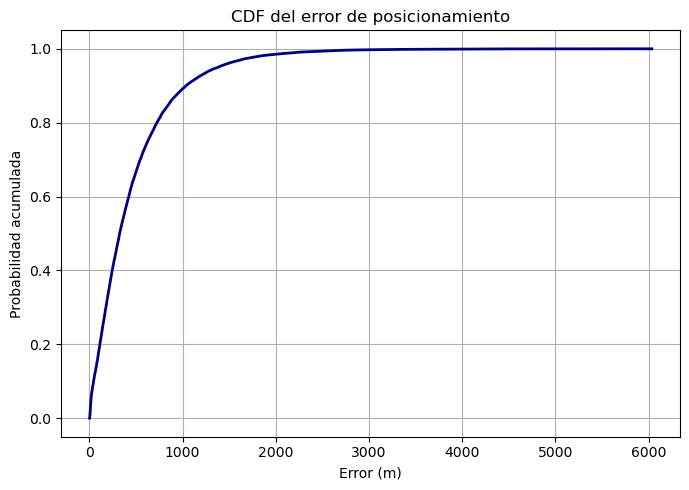

In [26]:
plt.figure(figsize=(7,5))
sorted_errors = np.sort(dist_test_knn3)
cdf = np.arange(len(sorted_errors)) / len(sorted_errors)
plt.plot(sorted_errors, cdf, color='navy', linewidth=2)
plt.title("CDF del error de posicionamiento")
plt.xlabel("Error (m)")
plt.ylabel("Probabilidad acumulada")
plt.grid(True)
plt.tight_layout()
plt.show()

# RF

In [7]:
start = time.time()

# Entrenamos con la mejor combinación de parámetros
rfr_opt = RandomForestRegressor(n_estimators=150,
                                max_depth=40,
                                min_samples_split=20,
                                min_samples_leaf=1,
                                random_state=42,
                                n_jobs=-1)
rfr_opt.fit(X_train_exp, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 5.80 segundos


In [8]:
start = time.time()

# TRAIN

y_train_pred_scaled = rfr_opt.predict(X_train_exp)
y_train_pred_rfr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_rfr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"RandomForest Mean: {dist_train.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = rfr_opt.predict(X_test_exp)
y_test_pred_rfr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_rfr[:, [1, 0]])

dist_test_rfr3 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"RandomForest Mean: {dist_test_rfr3.mean():.2f}")
print(f"RandomForest Median: {np.median(dist_test_rfr3):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
RandomForest Mean: 305.40
RandomForest Median: 215.10

TEST:
RandomForest Mean: 467.53
RandomForest Median: 325.92
Tiempo total: 15.36 segundos


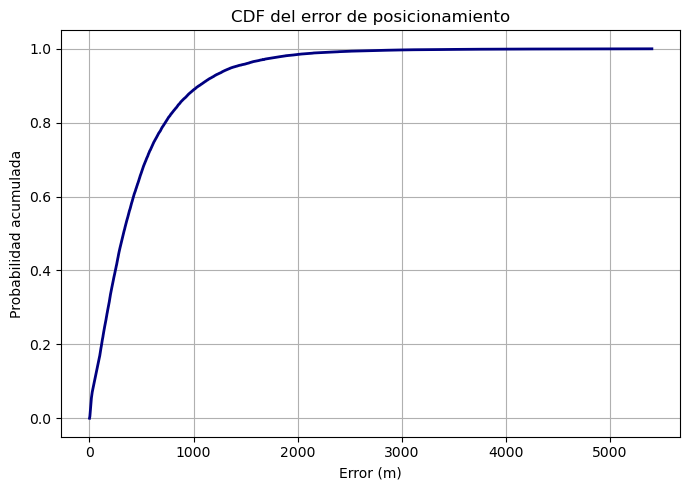

In [9]:
plt.figure(figsize=(7,5))
sorted_errors = np.sort(dist_test_rfr3)
cdf = np.arange(len(sorted_errors)) / len(sorted_errors)
plt.plot(sorted_errors, cdf, color='navy', linewidth=2)
plt.title("CDF del error de posicionamiento")
plt.xlabel("Error (m)")
plt.ylabel("Probabilidad acumulada")
plt.grid(True)
plt.tight_layout()
plt.show()

# ET

In [10]:
start = time.time()

# Entrenamos con la mejor combinación de parámetros
etr_opt = ExtraTreesRegressor(n_estimators=150,
                              max_depth=40,
                              min_samples_split=20,
                              min_samples_leaf=1,
                              random_state=42,
                              n_jobs=-1)
etr_opt.fit(X_train_pow, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 8.26 segundos


In [11]:
start = time.time()

# TRAIN

y_train_pred_scaled = etr_opt.predict(X_train_pow)
y_train_pred_etr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_etr[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"ExtraTrees Mean: {dist_train.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = etr_opt.predict(X_test_pow)
y_test_pred_etr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_etr[:, [1, 0]])

dist_test_etr2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"ExtraTrees Mean: {dist_test_etr2.mean():.2f}")
print(f"ExtraTrees Median: {np.median(dist_test_etr2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
ExtraTrees Mean: 294.32
ExtraTrees Median: 209.02

TEST:
ExtraTrees Mean: 459.17
ExtraTrees Median: 324.19
Tiempo total: 16.78 segundos


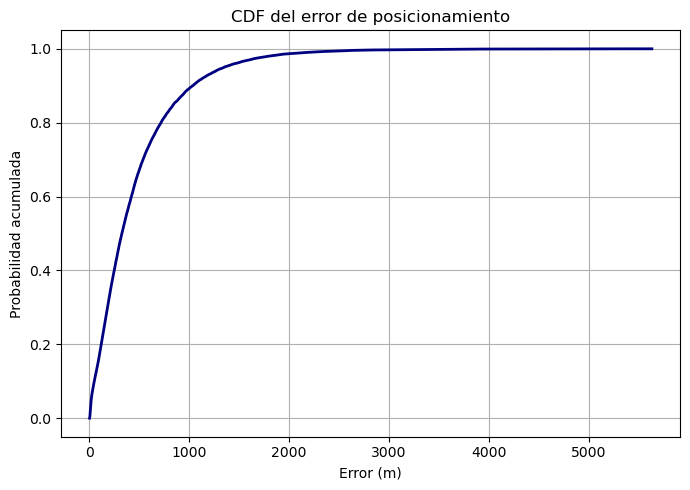

In [13]:
plt.figure(figsize=(7,5))
sorted_errors = np.sort(dist_test_etr2)
cdf = np.arange(len(sorted_errors)) / len(sorted_errors)
plt.plot(sorted_errors, cdf, color='navy', linewidth=2)
plt.title("CDF del error de posicionamiento")
plt.xlabel("Error (m)")
plt.ylabel("Probabilidad acumulada")
plt.grid(True)
plt.tight_layout()
plt.show()

# GB

In [14]:
start = time.time()

# Entrenamos con la mejor combinación de parámetros
gbr_opt = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=11,
    random_state=42))
gbr_opt.fit(X_train_pow, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 131.60 segundos


In [15]:
start = time.time()

# TRAIN

y_train_pred_scaled = gbr_opt.predict(X_train_pow)
y_train_pred_gbr = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_gbr[:, [1, 0]])

dist_train = np.array([
    haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000
#dist_train = haversine_distances(y_true_train_rad, y_pred_train_rad).diagonal() * 6371000

print('TRAIN:')
print(f"GradientBoosting Mean: {dist_train.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = gbr_opt.predict(X_test_pow)
y_test_pred_gbr = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_gbr[:, [1, 0]])

dist_test_gbr2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"GradientBoosting Mean: {dist_test_gbr2.mean():.2f}")
print(f"GradientBoosting Median: {np.median(dist_test_gbr2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
GradientBoosting Mean: 344.47
GradientBoosting Median: 256.19

TEST:
GradientBoosting Mean: 475.34
GradientBoosting Median: 349.43
Tiempo total: 15.89 segundos


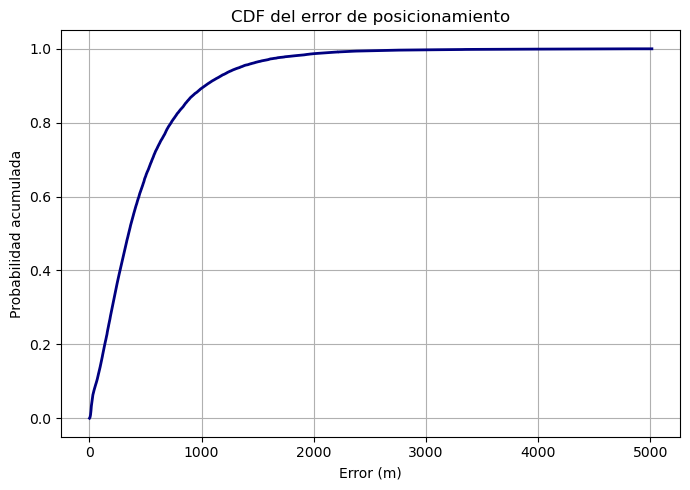

In [16]:
plt.figure(figsize=(7,5))
sorted_errors = np.sort(dist_test_gbr2)
cdf = np.arange(len(sorted_errors)) / len(sorted_errors)
plt.plot(sorted_errors, cdf, color='navy', linewidth=2)
plt.title("CDF del error de posicionamiento")
plt.xlabel("Error (m)")
plt.ylabel("Probabilidad acumulada")
plt.grid(True)
plt.tight_layout()
plt.show()

# MLP

In [18]:
# Definimos el modelo
mlp = MLPRegressor(
    hidden_layer_sizes=(256,128,64),
    #activation='relu',
    #solver='adam',
    #alpha=0.0001,
    batch_size=256,
    max_iter=300,
    early_stopping=True,
    random_state=42
)

In [19]:
start = time.time()

# Entrenamos el modelo
mlp.fit(X_train_pow, y_train_scaled)

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

Tiempo total: 39.91 segundos


In [20]:
start = time.time()

# TRAIN

y_train_pred_scaled = mlp.predict(X_train_pow)
y_train_pred_mlp = scaler_y.inverse_transform(y_train_pred_scaled)

y_true_train_rad = np.radians(y_train.iloc[:, [1, 0]].to_numpy())
y_pred_train_rad = np.radians(y_train_pred_mlp[:, [1, 0]])

dist_train = np.array([haversine_distances(
        [y_true_train_rad[i]],
        [y_pred_train_rad[i]]
    )[0][0]
    for i in range(len(y_true_train_rad))
]) * 6371000

print('TRAIN:')
print(f"MLP Mean: {dist_train.mean():.2f}")
print(f"MLP Median: {np.median(dist_train):.2f}")

# TEST

y_test_pred_scaled = mlp.predict(X_test_pow)
y_test_pred_mlp = scaler_y.inverse_transform(y_test_pred_scaled)

y_true_test_rad = np.radians(y_test.iloc[:, [1, 0]].to_numpy())
y_pred_test_rad = np.radians(y_test_pred_mlp[:, [1, 0]])

dist_test_mlp2 = np.array([
    haversine_distances(
        [y_true_test_rad[i]],
        [y_pred_test_rad[i]]
    )[0][0]
    for i in range(len(y_true_test_rad))
]) * 6371000

print('\nTEST:')
print(f"MLP Mean: {dist_test_mlp2.mean():.2f}")
print(f"MLP Median: {np.median(dist_test_mlp2):.2f}")

end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

TRAIN:
MLP Mean: 377.95
MLP Median: 273.66

TEST:
MLP Mean: 453.14
MLP Median: 326.35
Tiempo total: 19.05 segundos


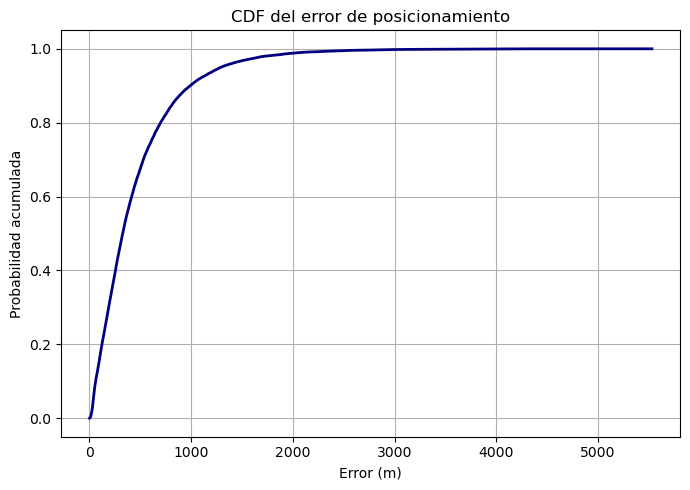

In [22]:
plt.figure(figsize=(7,5))
sorted_errors = np.sort(dist_test_mlp2)
cdf = np.arange(len(sorted_errors)) / len(sorted_errors)
plt.plot(sorted_errors, cdf, color='navy', linewidth=2)
plt.title("CDF del error de posicionamiento")
plt.xlabel("Error (m)")
plt.ylabel("Probabilidad acumulada")
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparamos

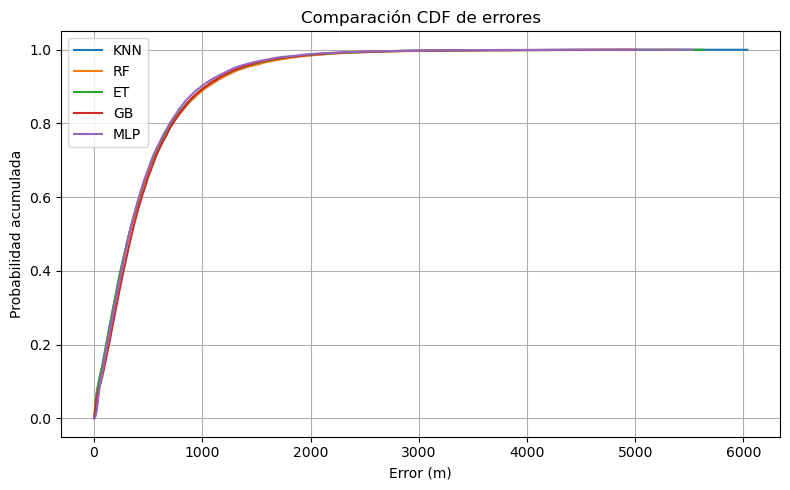

In [30]:
plt.figure(figsize=(8,5))

# KNN
sorted_knn = np.sort(dist_test_knn3)
cdf_knn = np.arange(len(sorted_knn)) / len(sorted_knn)

plt.plot(sorted_knn, cdf_knn, label='KNN')

# RF
sorted_rf = np.sort(dist_test_rfr3)
cdf_rf = np.arange(len(sorted_rf)) / len(sorted_rf)

plt.plot(sorted_rf, cdf_rf, label='RF')

# ET
sorted_et = np.sort(dist_test_etr2)
cdf_et = np.arange(len(sorted_et)) / len(sorted_et)

plt.plot(sorted_et, cdf_et, label='ET')

# GB
sorted_gb = np.sort(dist_test_gbr2)
cdf_gb = np.arange(len(sorted_gb)) / len(sorted_gb)

plt.plot(sorted_gb, cdf_gb, label='GB')

# MLP

sorted_mlp = np.sort(dist_test_mlp2)
cdf_mlp = np.arange(len(sorted_mlp)) / len(sorted_mlp)

plt.plot(sorted_mlp, cdf_mlp, label='MLP')

plt.xlabel("Error (m)")
plt.ylabel("Probabilidad acumulada")

plt.title("Comparación CDF de errores")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()